In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
m = 1000 # Number of iterations to run RWMH for each parameter value
n = 100 # Number of dimensions to test over
seed = 0 # Seed for random number generator
X0 = 0 # Initial value for all tests

In [ ]:
# Log-acceptance probability
def log_r(x, y):
  return 0.5 * (np.linalg.norm(x)**2 - np.linalg.norm(y)**2)

In [ ]:
# RWMH step
def step(x, beta, xi, U):

  px = x + beta * xi
  acc = min(0,log_r(x, px))

  if acc < U:
    y = x
    success = 0

  else:
    y = px
    success = 1

  return y, acc, success

In [ ]:
# Scaling with fixed beta = 0.3
beta = 0.3
E_log_r = np.zeros(n)
E_alpha = np.zeros(n)

for i in range(n):

  np.random.seed(seed + i)
  xis = np.random.normal(size=(m,i))
  Us = np.log(np.random.uniform(0,1,m))

  rval = 0
  sval = 0
  x = X0

  for j in range(m):

    x, r, s = step(x, beta, xis[j], Us[j])
    rval += r
    sval += s

  rval /= m
  sval /= m
  E_log_r[i] = rval
  E_alpha[i] = sval

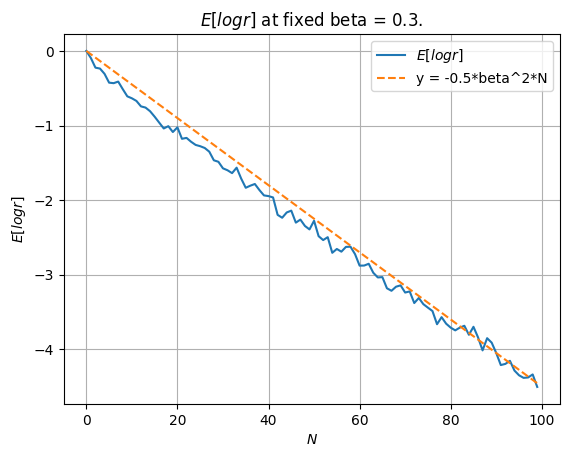

In [ ]:
fig, ax = plt.subplots()
xvals = np.arange(0,n)
ax.plot(xvals,E_log_r,label='$E[log r]$')
ax.plot(xvals,-0.09*xvals/2,'--',label='y = -0.5*beta^2*N')
ax.set_title('$E[logr]$ at fixed beta = 0.3.')
ax.set_ylabel('$E[log r]$')
ax.set_xlabel('$N$')
ax.grid()
ax.legend()
plt.show()

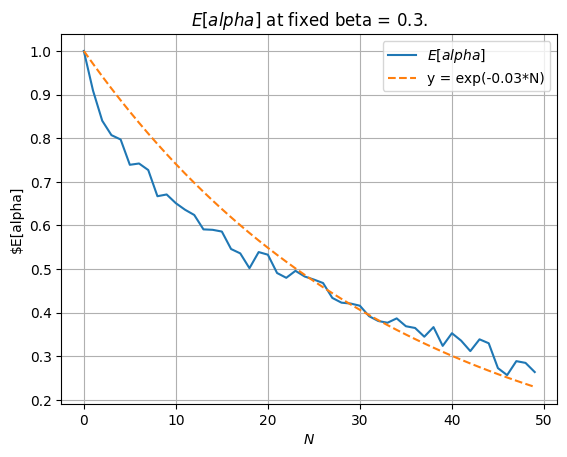

In [ ]:
fig, ax = plt.subplots()
ax.plot(xvals[:50],E_alpha[:50],label='$E[alpha]$')
ax.plot(xvals[:50], np.exp(-0.03*xvals[:50]),'--',label='y = exp(-0.03*N)')
ax.set_title('$E[alpha]$ at fixed beta = 0.3.')
ax.set_ylabel('$E[alpha]')
ax.set_xlabel('$N$')
ax.legend()
ax.grid()
plt.show()

In [ ]:
# Scaling with beta = N**(-0.5)

E_log_r_2 = np.zeros(n)
E_alpha_2 = np.zeros(n)

for i in range(n):

  np.random.seed(seed + i)
  xis = np.random.normal(size=(m,i))
  Us = np.log(np.random.uniform(0,1,m))

  rval = 0
  sval = 0
  x = X0

  for j in range(m):

    x, r, s = step(x, n**(-0.5), xis[j], Us[j])
    rval += r
    sval += s

  rval /= m
  sval /= m
  E_log_r_2[i] = rval
  E_alpha_2[i] = sval

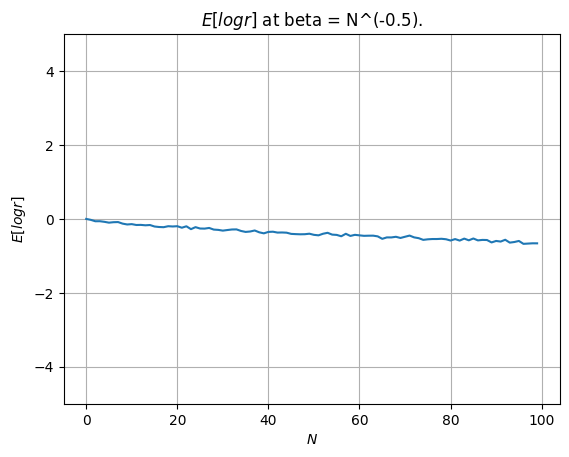

In [ ]:
fig, ax = plt.subplots()
xvals = np.arange(0,n)
ax.plot(xvals,E_log_r_2,label='$E[log r]$')
ax.set_title('$E[log r]$ at beta = N^(-0.5).')
ax.set_ylabel('$E[log r]$')
ax.set_xlabel('$N$')
ax.set_ylim(-5,5)
ax.grid()
plt.show()

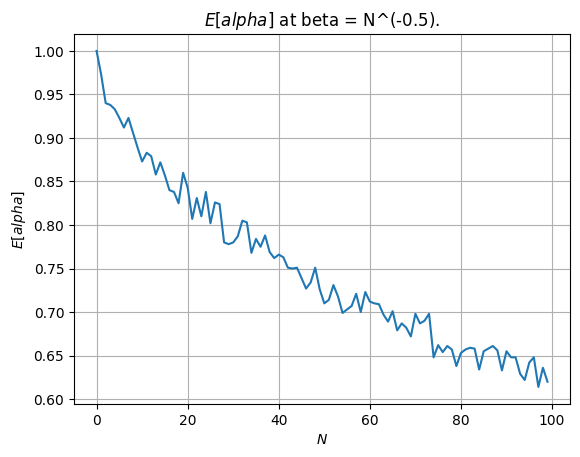

In [ ]:
fig, ax = plt.subplots()
ax.plot(xvals,E_alpha_2,label='$E[alpha]$')
ax.set_title('$E[alpha]$ at beta = N^(-0.5).')
ax.set_ylabel('$E[alpha]$')
ax.set_xlabel('$N$')
ax.grid()
plt.show()